In [6]:
# 計算隔天當沖準確率（開盤買進收盤賣出or開盤賣出收盤回補）
def eval(signal_l, price):
    '''
        signal: list, [日期, 評分]
        price: dataframe, 股票價格

        return: float, float 準確率, 平均報酬率
    '''
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    rtns_gain = []   # 記錄當日沖銷的報酬率
    rtns_loss = []   # 記錄當日沖銷的報酬率


    for idx, item in enumerate(signal_l):
        signal = float(item[1])
        index_location = price.index.get_loc(item[0])  # 獲取特定索引的位置
        if index_location == len(price.index) - 1: # 避免超出索引
            break
        next_index = price.index[index_location + 1]  # 獲取下一個索引的位置
        next_row = price.loc[next_index]  # 找到下一個索引的列
        open = float(next_row['Open'])
        close = float(next_row['Close'])
        
        if signal > 0:
            
            if close > open:
                rtns_gain.append(close/open)
                tp += 1
            elif close < open:
                rtns_loss.append(close/open)
                fp += 1
            else:   
                pass

        elif signal < 0:

            if close < open:
                rtns_gain.append(open/close)
                tn += 1
            elif close > open:
                rtns_loss.append(open/close)
                fn += 1
            else:   
                pass
    if (tp + tn + fp + fn)  == 0:
        accuracy = 0
    else:
        accuracy = (tp + tn) / (tp + tn + fp + fn) # 準確率
        # print(tp, tn, fp, fn)

    if len(rtns_gain) == 0:
        avg_gain = 1.0
    else:
        avg_gain = sum(rtns_gain)/len(rtns_gain)  # 這檔股票在這段時間的平均報酬率
        # print(avg_rtn)

    if len(rtns_gain) == 0:
        avg_loss = 1.0
    else:
        avg_loss = sum(rtns_loss)/len(rtns_loss)  # 這檔股票在這段時間的平均報酬率
        # print(avg_rtn)

    ev = (avg_gain * accuracy) - (avg_loss * (1 - accuracy))  # 期望值
    return accuracy, avg_gain, avg_loss, ev

In [16]:
import os
import json
import pandas as pd
file_list = os.listdir('eval_s2a/output0601')
stock_ids = [] 
acc_1 = []
acc_2 = []
ev_1 = []
ev_2 = []


for i in range(len(file_list)):
    id = file_list[i].split('detail')[0]
    stock_ids.append(id)
    df_price = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + id + "twse.csv", dtype=str)
    df_price.set_index('Date', inplace=True)  # 將'Date'行設置為索引

    # print(df_price.head())

    # 讀取json檔案
    with open('eval_s2a/output/' + file_list[i], 'r') as f:
        signal_l = json.load(f)
    with open('eval_s2a/output0601/' + file_list[i], 'r') as f:
        signal_s2a = json.load(f)
    # print(signal_l['raw_data'])

    acc , r1, r2, ev = eval(signal_l['raw_data'], df_price)
    acc_1.append(acc)

    ev_1.append(ev)
    # print("output     : " + str(eval_result))
    acc , r1, r2, ev = eval(signal_s2a['raw_data'], df_price)
    acc_2.append(acc)
    ev_2.append(ev)
    # print("output s2a : " + str(eval_result_s2a))

print(acc_1)
print(acc_2)
print()
print(ev_1)
print(ev_2)

[0.5350877192982456, 0.6179775280898876, 0.4774193548387097, 0.5977011494252874, 0.5555555555555556]
[0.5350877192982456, 0.6179775280898876, 0.4774193548387097, 0.5977011494252874, 0.5777777777777777]

[0.07604515351688435, 0.2520016581510229, -0.03933074769602396, 0.20981457975202045, 0.12343532244332733]
[0.07604515351688435, 0.2520016581510229, -0.03933045068445662, 0.20981457975202045, 0.16790536950831092]


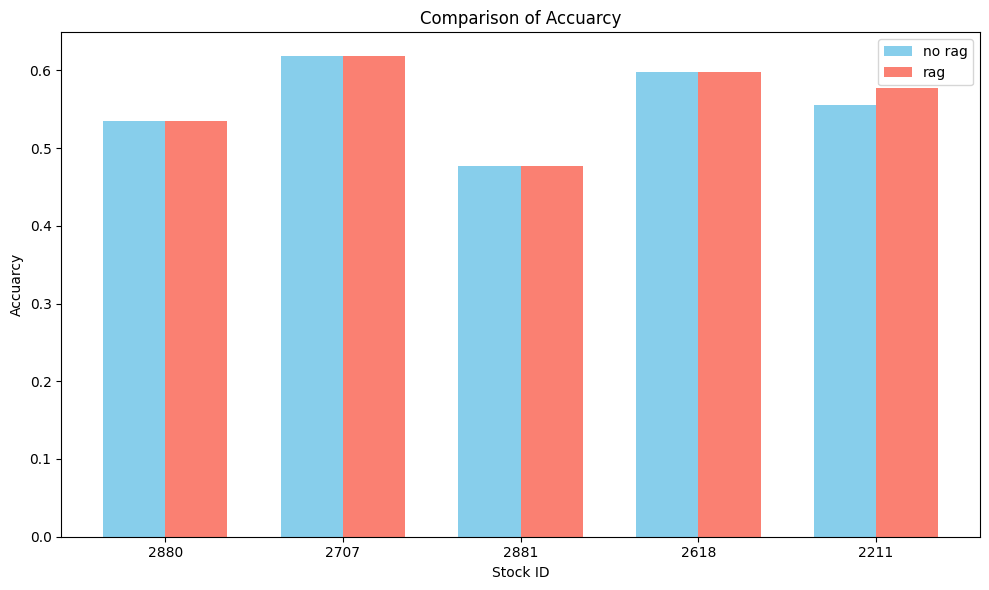

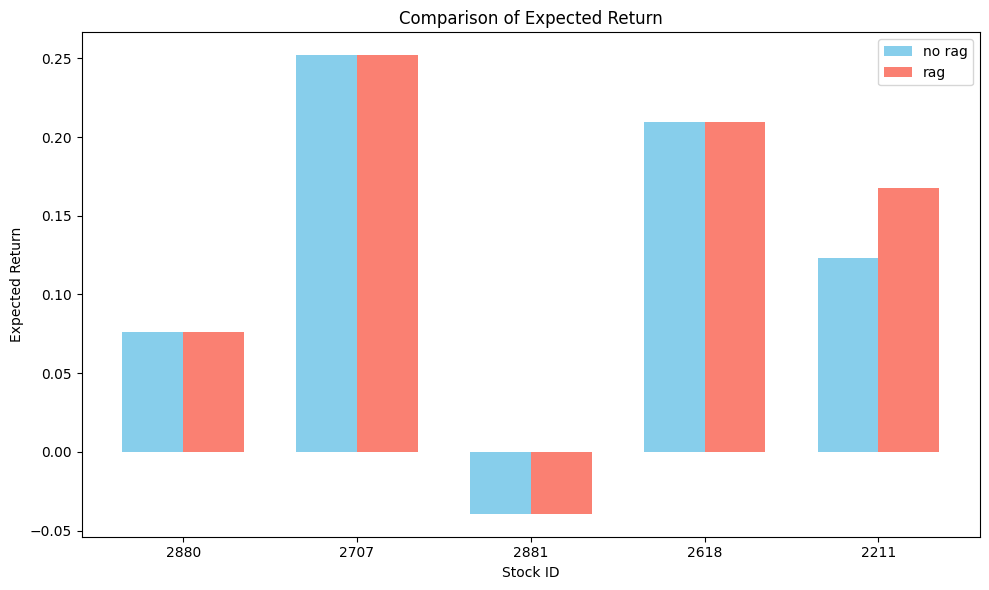

In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, acc_1, width, label='no rag', color='skyblue')
bars2 = ax.bar(x + width/2, acc_2, width, label='rag', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

# 繪製準確率長條圖
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, ev_1, width, label='no rag', color='skyblue')
bars2 = ax.bar(x + width/2, ev_2, width, label='rag', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Return')
ax.set_title('Comparison of Expected Return')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
# ax.set_ylim([0, None])  
plt.tight_layout()
plt.show()

